<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº 3 - FFT, desparramo, interpolación y ventaneo
#### HOFFENREICH JULIETA


# Introducción

Durante este trabajo se analizó el fenómeno de **desparramo espectral** que puede aparecer al calcular la Transformada Discreta de Fourier (DFT) de una señal de duración finita.

Para realizar el análisis se generaron tres señales senoidales de $N=1000$ muestras, con una frecuencia de muestreo de $f_s=1000\,Hz$. La resolución frecuencial correspondiente es:

$$\Delta f=\frac{f_s}{N}=1\,Hz$$

Se buscó que las señales tuvieran **potencia media unitaria**, por lo que se utilizó una amplitud $A=\sqrt{2}$.

Las frecuencias se definieron a partir de:

$$f_0=k_0\Delta f$$

considerando los casos $k_0=N/4$, $k_0=N/4+0.25$ y $k_0=N/4+0.5$, que corresponden a frecuencias de $250\,Hz$, $250.25\,Hz$ y $250.5\,Hz$, respectivamente.

Al trabajar con una cantidad finita de muestras, la señal queda implícitamente multiplicada por una **ventana rectangular** de longitud $N$. En el dominio frecuencial, la transformada de esta ventana presenta una forma tipo **sinc**, cuyos ceros se encuentran separados por $\Delta f$. Es decir, alrededor de la frecuencia en la que está centrada la sinc, sus ceros aparecen cada $\Delta f$.
Cuando la frecuencia de la senoidal no coincide exactamente con la grilla frecuencial de la DFT, estos ceros dejan de coincidir con los bins y la potencia se distribuye entre varios de ellos. Este efecto se conoce como **desparramo espectral**.

También se verificó la potencia de las señales mediante la **identidad de Parseval**, que establece una equivalencia entre la energía calculada en el dominio temporal y en el dominio frecuencial. Para una señal discreta de $N$ muestras:

$$\sum_{n=0}^{N-1}|x[n]|^2=\frac{1}{N}\sum_{k=0}^{N-1}|X[k]|^2$$

Finalmente, se estudió la técnica de **zero padding**, que consiste en agregar ceros al final de la señal original antes de calcular la FFT. En este caso se agregaron $9N$ ceros, obteniendo un vector de longitud total $10N$. Esto genera una grilla frecuencial más densa y permite visualizar con mayor detalle la forma del espectro, aunque no agrega nueva información a la señal ni elimina el desparramo espectral.


# Análisis y Resultados

En primer lugar se generaron las tres señales senoidales correspondientes a $f_0=250\,Hz$, $f_0=250.25\,Hz$ y $f_0=250.5\,Hz$, todas con amplitud $A=\sqrt{2}$ para obtener potencia media unitaria. Inicialmente se graficaron en el **dominio temporal** para comparar su comportamiento en función del tiempo.

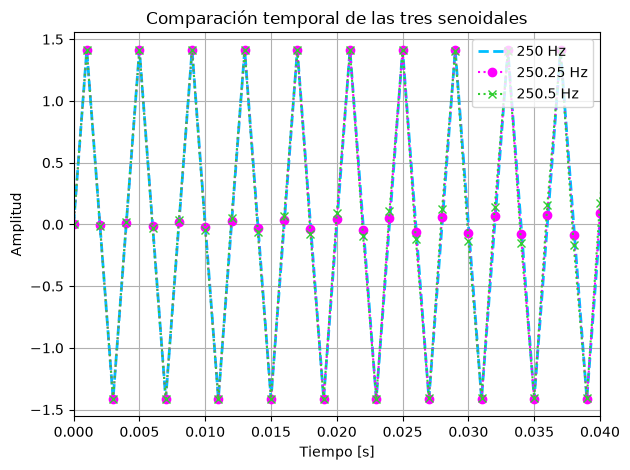

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#%% PARÁMETROS Y FUNCIONES

N = 1000
fs = 1000
df = fs / N

def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):
    tt = np.arange(0, nn/fs, 1/fs)
    xx = dc + vmax * np.sin(2*np.pi*ff*tt + ph)
    return tt, xx
    
# Valores de k0
k0_1 = N/4
k0_2 = N/4 + 0.25
k0_3 = N/4 + 0.5

# Frecuencias
f0_1 = k0_1 * df
f0_2 = k0_2 * df
f0_3 = k0_3 * df

# Amplitud para potencia unitaria
A = np.sqrt(2)

#%% GENERAMOS LAS 3 SENOIDALES
t, x1 = mi_funcion_sen(vmax=A, dc=0, ff=f0_1, ph=0, nn=N, fs=fs)
_, x2 = mi_funcion_sen(vmax=A, dc=0, ff=f0_2, ph=0, nn=N, fs=fs)
_, x3 = mi_funcion_sen(vmax=A, dc=0, ff=f0_3, ph=0, nn=N, fs=fs)
#Obs: usamos _, porque las 3 senales tienen exactamente el mismo vector de tiempo, 
#entonces nos basta con guardar uno solo, no hace falta t1, t2, t3

#%% GRÁFICO TEMPORAL
plt.figure()
plt.plot(t,x1,color='deepskyblue',linestyle='--',linewidth=2,label='250 Hz')
plt.plot(t,x2,':o',color='magenta',label='250.25 Hz')
plt.plot(t,x3,':x',color='limegreen',label='250.5 Hz')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Comparación temporal de las tres senoidales')
plt.xlim(0,0.04)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()
#aunque temporalmente las señales parecen muy similares, su DFT puede resultar muy diferente dependiendo de si la frecuencia coincide o no con los bins.

Como puede observarse en la figura, en el dominio temporal las tres señales presentan un comportamiento muy similar debido a la pequeña diferencia entre sus frecuencias. Sin embargo, que las señales sean parecidas en el tiempo no implica que su representación en frecuencia también lo sea.

Para estudiar este comportamiento se pasó al **dominio frecuencial** mediante el cálculo de la Transformada Discreta de Fourier (DFT). De esta forma se puede analizar cómo influye la posición de cada frecuencia respecto de los bins de la DFT y observar el fenómeno de desparramo espectral.

### Cálculo de la DFT y potencia espectral

Se calculó la DFT de cada una de las tres señales mediante la FFT. Como las señales son reales, su espectro presenta simetría conjugada, por lo que la mitad negativa contiene información redundante. Por este motivo se conservó únicamente la mitad positiva del espectro, correspondiente al intervalo entre $0$ y $f_s/2$.

Para obtener una representación en potencia se utilizó:

$$P[k]=2\left|\frac{X[k]}{N}\right|^2$$

El cociente por $N$ permite normalizar la amplitud de la FFT y el módulo al cuadrado permite obtener potencia. El factor $2$ aparece porque se representa únicamente la mitad positiva del espectro, incorporando en ella la contribución correspondiente a la mitad negativa descartada.

Finalmente, la potencia se expresó en decibeles mediante:

$$P_{dB}[k]=10\log_{10}(P[k])$$

La escala en dB permite visualizar con mayor claridad diferencias de potencia de varios órdenes de magnitud y facilita la observación del desparramo espectral.


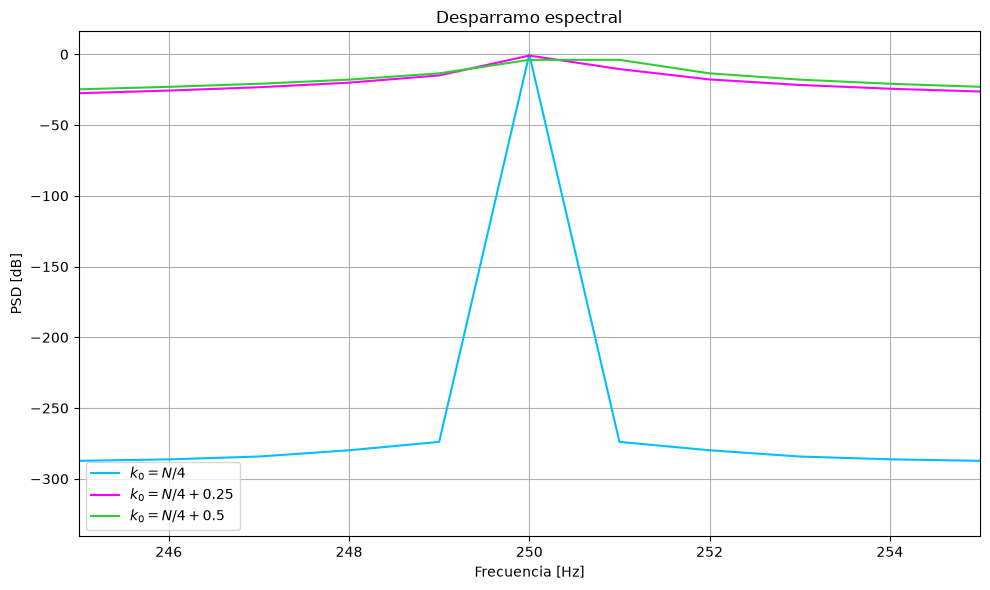

In [3]:
#%% PARTE A - DFT

# Calculamos DFT
X1 = np.fft.fft(x1)
X2 = np.fft.fft(x2)
X3 = np.fft.fft(x3)

# Eje de frecuencias
f = np.arange(N//2) * df

# PSD unilat. 
P1 = 2*np.abs(X1[:N//2]/N)**2
P2 = 2*np.abs(X2[:N//2]/N)**2
P3 = 2*np.abs(X3[:N//2]/N)**2
#elevo al cuadrado x potencia y /N para normalizar amp, nos quedamos con la mitad porque la otra es redundante x senal real y multiplicamos por 2 para represen la pot real en esa mitad

#en db
P1_dB = 10*np.log10(P1)
P2_dB = 10*np.log10(P2)
P3_dB = 10*np.log10(P3)


#GRÁFICO PARTE A

plt.figure(figsize=(10,6))
plt.plot(f, P1_dB, label=r'$k_0=N/4$', color='deepskyblue')
plt.plot(f, P2_dB, label=r'$k_0=N/4+0.25$', color='magenta')
plt.plot(f, P3_dB, label=r'$k_0=N/4+0.5$',color='limegreen')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.title('Desparramo espectral')
plt.grid()
plt.legend()
plt.xlim(245, 255)
plt.tight_layout()
plt.show()


En la figura se observa que, aunque las tres frecuencias difieren solamente en fracciones de $\Delta f$, su representación mediante la DFT cambia considerablemente.

Para $k_0=N/4$, la frecuencia de la señal es exactamente $250\,Hz$, por lo que coincide con uno de los bins de la DFT. En este caso, la potencia queda prácticamente concentrada en ese bin y los demás valores son muy pequeños, por lo que no se observa un desparramo espectral significativo.

Cuando $k_0=N/4+0.25$, la frecuencia pasa a ser $250.25\,Hz$. Esta frecuencia ya no coincide exactamente con la grilla de la DFT, cuyos bins están separados por $\Delta f=1\,Hz$. Como consecuencia, la potencia deja de concentrarse en un único bin y comienza a distribuirse entre varios bins vecinos.

Para $k_0=N/4+0.5$, la frecuencia es $250.5\,Hz$, ubicada exactamente a mitad de camino entre los bins de $250\,Hz$ y $251\,Hz$. En este caso, la potencia se reparte de manera más evidente entre ambos bins y también aparece distribuida en bins cercanos.

Por lo tanto, una pequeña desintonía respecto de la grilla frecuencial puede modificar considerablemente la representación obtenida mediante la DFT, aun cuando las señales sean muy similares en el dominio temporal.

### ¿Por qué una pequeña diferencia de frecuencia produce espectros tan distintos?

En principio, podría pensarse que una senoidal de $250.25\,Hz$ debería presentar en su espectro únicamente una delta en $250.25\,Hz$. Esto es cierto para una senoidal ideal de duración infinita. Sin embargo, en este trabajo se utilizan señales finitas, de $N=1000$ muestras.

Tomar solamente $N$ muestras de una señal equivale a multiplicarla, de manera implícita, por una **ventana rectangular** de longitud $N$. La multiplicación en el dominio temporal se transforma en una convolución en el dominio frecuencial:

$$x[n]\,w[n]\longleftrightarrow X(f)*W(f)$$

La transformada de la ventana rectangular tiene una forma tipo **sinc**. Por lo tanto, las deltas ideales correspondientes a la senoidal se convolucionan con esta función. Como convolucionar con una delta desplazada produce la misma función desplazada, alrededor de cada frecuencia de la senoidal aparece una sinc centrada en $f_0$. Al representar potencia, lo que se observa corresponde al módulo al cuadrado de esta forma.

Cuando $f_0$ coincide exactamente con un bin de la DFT, por ejemplo $f_0=250\,Hz$, el máximo de la sinc coincide con ese bin y sus ceros coinciden con los demás bins de la DFT. Esto ocurre porque los ceros de la sinc están separados por $\Delta f$. En este caso aparecen, por ejemplo, en $249\,Hz$, $248\,Hz$, $247\,Hz$, etc., y en $251\,Hz$, $252\,Hz$, $253\,Hz$, etc.

Por este motivo, al evaluar la DFT prácticamente toda la potencia aparece concentrada en el bin correspondiente a $250\,Hz$.

En cambio, cuando la frecuencia se desintoniza, por ejemplo a $250.25\,Hz$ o $250.5\,Hz$, toda la sinc se desplaza. Sus ceros dejan de coincidir con los puntos donde la DFT toma sus muestras y aparecen valores distintos de cero en los bins vecinos. Como consecuencia, la potencia se distribuye entre varios bins y aparece el **desparramo espectral**.

Esto explica por qué una diferencia de apenas $0.25\,Hz$ puede producir un cambio importante en la DFT, aunque las señales sean muy parecidas en el dominio temporal.

Para visualizar mejor este comportamiento, utilicé la IA para generar una representación que permitiera comparar la forma continua del espectro con los puntos evaluados por la DFT.

En la siguiente figura, la línea continua representa una aproximación muy densa de la DTFT, obtenida evaluando el espectro sobre una grilla frecuencial mucho más fina. Los puntos representan las muestras tomadas por la DFT original, separadas por $\Delta f=1\,Hz$.


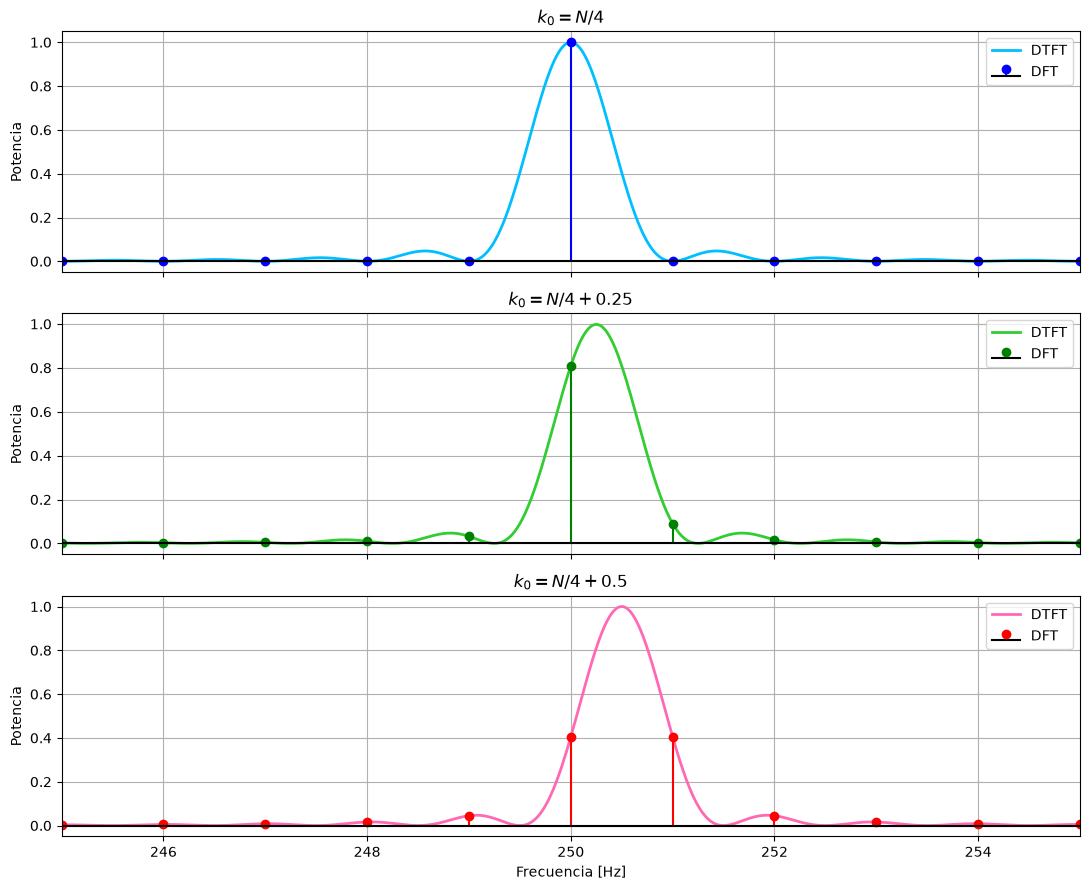

In [5]:
#%% PARTE B.2 - DTFT CONTINUA Y MUESTRAS DE LA DFT

# Grilla muy fina para visualizar la DTFT
N_dtft = 100*N
f_dtft = np.arange(N_dtft//2)*fs/N_dtft

# FFT muy densa -> aproximación visual de la DTFT
X1_dtft = np.fft.fft(x1,n=N_dtft)[:N_dtft//2]
X2_dtft = np.fft.fft(x2,n=N_dtft)[:N_dtft//2]
X3_dtft = np.fft.fft(x3,n=N_dtft)[:N_dtft//2]

# Potencia de la curva continua
P1_dtft = 2*np.abs(X1_dtft/N)**2
P2_dtft = 2*np.abs(X2_dtft/N)**2
P3_dtft = 2*np.abs(X3_dtft/N)**2

# Potencia de las muestras de la DFT
# IMPORTANTE: misma normalización que la curva continua
P1_dft = 2*np.abs(X1[:N//2]/N)**2
P2_dft = 2*np.abs(X2[:N//2]/N)**2
P3_dft = 2*np.abs(X3[:N//2]/N)**2

fig,ax = plt.subplots(3,1,figsize=(11,9),sharex=True)

ax[0].plot(f_dtft,P1_dtft,color='deepskyblue',linewidth=2,label='DTFT')
ax[0].stem(f,P1_dft,linefmt='b-',markerfmt='bo',basefmt='k-',label='DFT')
ax[0].set_title(r'$k_0=N/4$')
ax[0].set_ylabel('Potencia')
ax[0].grid()
ax[0].legend()

ax[1].plot(f_dtft,P2_dtft,color='limegreen',linewidth=2,label='DTFT')
ax[1].stem(f,P2_dft,linefmt='g-',markerfmt='go',basefmt='k-',label='DFT')
ax[1].set_title(r'$k_0=N/4+0.25$')
ax[1].set_ylabel('Potencia')
ax[1].grid()
ax[1].legend()

ax[2].plot(f_dtft,P3_dtft,color='hotpink',linewidth=2,label='DTFT')
ax[2].stem(f,P3_dft,linefmt='r-',markerfmt='ro',basefmt='k-',label='DFT')
ax[2].set_title(r'$k_0=N/4+0.5$')
ax[2].set_ylabel('Potencia')
ax[2].set_xlabel('Frecuencia [Hz]')
ax[2].grid()
ax[2].legend()

plt.xlim(245,255)
plt.tight_layout()
plt.show()

En el primer caso, $k_0=N/4$, se observa que el máximo se encuentra exactamente en $250\,Hz$ y los demás bins coinciden con los ceros de la sinc. Por eso la DFT detecta prácticamente potencia únicamente en ese bin.

Para $k_0=N/4+0.25$, la sinc se desplaza hacia $250.25\,Hz$. Como la DFT continúa evaluando en $250\,Hz$, $251\,Hz$, $252\,Hz$, etc., sus muestras ya no coinciden con los ceros y aparecen componentes en varios bins.

Finalmente, para $k_0=N/4+0.5$, el máximo queda exactamente entre los bins de $250\,Hz$ y $251\,Hz$. Ambos puntos toman entonces valores importantes y la potencia aparece distribuida entre ellos y los bins cercanos.

De esta manera, la DFT puede interpretarse como un conjunto de muestras de la DTFT tomadas cada $\Delta f$. La posición de la sinc respecto de esos puntos determina cómo se observa el desparramo espectral.

### Verificación de potencia mediante la identidad de Parseval

Para comprobar que el desparramo espectral no implica una pérdida de potencia, se utilizó la **identidad de Parseval**, que permite relacionar la potencia calculada en el dominio temporal con la calculada en el dominio frecuencial.

En el dominio temporal, la potencia media se calcula como:

$$P_x=\frac{1}{N}\sum_{n=0}^{N-1}|x[n]|^2$$

En el dominio frecuencial, aplicando Parseval:

$$P_x=\frac{1}{N^2}\sum_{k=0}^{N-1}|X[k]|^2$$

Por este motivo, en el código la potencia temporal se obtiene mediante `np.mean(x**2)`, mientras que en frecuencia se calcula sumando el módulo al cuadrado de todos los coeficientes de la DFT y dividiendo por $N^2$.

In [6]:
#%% PARTE B - PARSEVAL

# Potencia en tiempo
Px1_t = np.mean(x1**2)
Px2_t = np.mean(x2**2)
Px3_t = np.mean(x3**2)

# Potencia usando Parseval
Px1_f = np.sum(np.abs(X1)**2) / N**2
Px2_f = np.sum(np.abs(X2)**2) / N**2
Px3_f = np.sum(np.abs(X3)**2) / N**2


print("Señal 1")
print("Potencia en tiempo:", Px1_t)
print("Potencia por Parseval:", Px1_f)
print()

print("Señal 2")
print("Potencia en tiempo:", Px2_t)
print("Potencia por Parseval:", Px2_f)
print()

print("Señal 3")
print("Potencia en tiempo:", Px3_t)
print("Potencia por Parseval:", Px3_f)
print()

#CONLSUION ; haya desparramo o no la energ se mantiene igual.


Señal 1
Potencia en tiempo: 1.0000000000000002
Potencia por Parseval: 1.0000000000000002

Señal 2
Potencia en tiempo: 0.9989999999999996
Potencia por Parseval: 0.9989999999999996

Señal 3
Potencia en tiempo: 1.0000000000000004
Potencia por Parseval: 1.0000000000000004



Los resultados muestran que, para cada una de las tres señales, la potencia calculada en el dominio temporal coincide con la obtenida mediante Parseval y resulta aproximadamente unitaria, como era de esperarse debido a la amplitud elegida para las senoidales.

Esto permite verificar que la desintonía no produce una pérdida de potencia. Lo que cambia es la forma en que esa potencia se distribuye entre los distintos bins de la DFT: cuando la frecuencia coincide con un bin, la potencia queda concentrada; cuando existe desintonía, la misma potencia total se distribuye entre varios bins debido al desparramo espectral.

### Zero padding

Finalmente se aplicó la técnica de **zero padding** para observar el espectro sobre una grilla frecuencial más densa. Para ello, a cada señal original de $N$ muestras se le agregaron $9N$ ceros al final, obteniendo un vector de longitud total: $N_{pad}=10N$

Los primeros $N$ valores corresponden a la señal original y los restantes son ceros. Luego se calculó nuevamente la FFT de cada señal.

Al aumentar la cantidad de puntos utilizados para calcular la FFT, la separación entre los puntos del eje frecuencial pasa de:

$$\Delta f=\frac{f_s}{N}=1\,Hz$$

a:

$$\Delta f_{pad}=\frac{f_s}{10N}=0.1\,Hz$$

Es importante destacar que el zero padding **no agrega información nueva a la señal ni mejora la resolución espectral real**, ya que se siguen teniendo solamente $N$ muestras reales. Lo que permite es obtener una grilla frecuencial más densa y visualizar con mayor detalle la forma del espectro entre los bins originales.

Para mantener la misma escala que en el caso sin padding, la FFT continúa normalizándose por $N$ y no por $N_{pad}$, ya que las muestras reales de la señal siguen siendo $N$.

Delta f sin padding = 1.0 Hz
Delta f con padding = 0.1 Hz


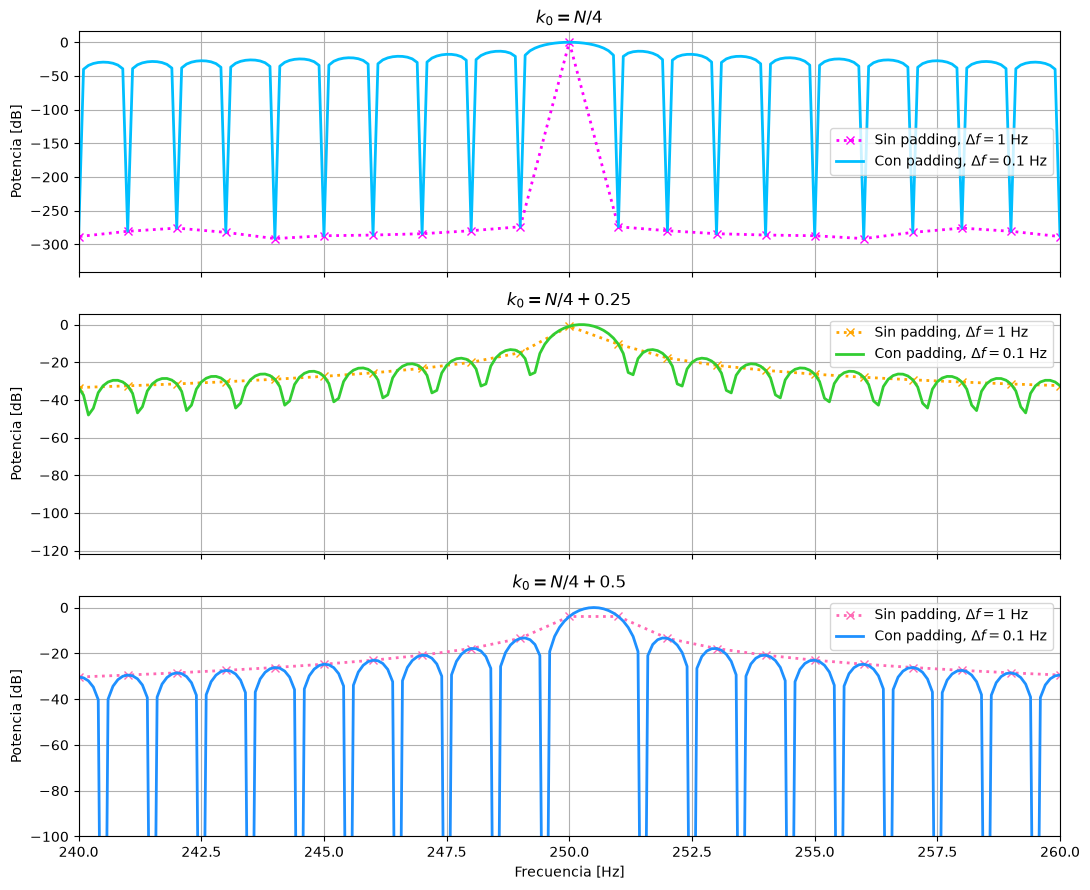

In [7]:
#%% PARTE C - ZERO PADDING

# Longitud total: N muestras originales + 9*N ceros
N_pad = 10 * N

# Creamos los vectores de zero padding
x1_pad = np.zeros(N_pad)
x2_pad = np.zeros(N_pad)
x3_pad = np.zeros(N_pad)

# Copiamos las señales originales en las primeras N posiciones
x1_pad[:N] = x1
x2_pad[:N] = x2
x3_pad[:N] = x3

# FFT de las señales padeadas
X1_pad = np.fft.fft(x1_pad)
X2_pad = np.fft.fft(x2_pad)
X3_pad = np.fft.fft(x3_pad)

# Resoluciónes frecuenciales
df = fs / N
df_pad = fs / N_pad #con zero padding

print("Delta f sin padding =", df, "Hz")
print("Delta f con padding =", df_pad, "Hz")


# Eje de frecuencias con zero padding
f_pad = np.arange(N_pad//2) * df_pad


# PSD unilateral CON padding
# IMPORTANTE: seguimos dividiendo por N, no por N_pad --> xq seguimos teniendo N muestras reles de la senal
P1_pad = 2*np.abs(X1_pad[:N_pad//2]/N)**2
P2_pad = 2*np.abs(X2_pad[:N_pad//2]/N)**2
P3_pad = 2*np.abs(X3_pad[:N_pad//2]/N)**2

# Pasamos a dB
P1_pad_dB = 10*np.log10(P1_pad)
P2_pad_dB = 10*np.log10(P2_pad)
P3_pad_dB = 10*np.log10(P3_pad)

# PSD
P1_pad = np.abs(X1_pad / N)**2
P2_pad = np.abs(X2_pad / N)**2
P3_pad = np.abs(X3_pad / N)**2

#%% COMPARACIÓN CON Y SIN ZERO PADDING

fig,ax = plt.subplots(3,1,figsize=(11,9),sharex=True)

ax[0].plot(f,P1_dB,':x',color='magenta',linewidth=2,label=r'Sin padding, $\Delta f=1$ Hz')
ax[0].plot(f_pad,P1_pad_dB,color='deepskyblue',linewidth=2,label=r'Con padding, $\Delta f=0.1$ Hz')
ax[0].set_title(r'$k_0=N/4$')
ax[0].set_ylabel('Potencia [dB]')
ax[0].grid()
ax[0].legend()

ax[1].plot(f,P2_dB,':x',color='orange',linewidth=2,label=r'Sin padding, $\Delta f=1$ Hz')
ax[1].plot(f_pad,P2_pad_dB,color='limegreen',linewidth=2,label=r'Con padding, $\Delta f=0.1$ Hz')
ax[1].set_title(r'$k_0=N/4+0.25$')
ax[1].set_ylabel('Potencia [dB]')
ax[1].grid()
ax[1].legend()

ax[2].plot(f,P3_dB,':x',color='hotpink',linewidth=2,label=r'Sin padding, $\Delta f=1$ Hz')
ax[2].plot(f_pad,P3_pad_dB,color='dodgerblue',linewidth=2,label=r'Con padding, $\Delta f=0.1$ Hz')
ax[2].set_title(r'$k_0=N/4+0.5$')
ax[2].set_ylabel('Potencia [dB]')
ax[2].set_xlabel('Frecuencia [Hz]')
ax[2].grid()
ax[2].legend()

plt.xlim(240,260)
plt.ylim(-100,5)
plt.tight_layout()
plt.show()

En la figura se compara, para cada frecuencia, el espectro original con $\Delta f=1\,Hz$ y el obtenido mediante zero padding con $\Delta f_{pad}=0.1\,Hz$.

Se observa que el zero padding no modifica los valores que ya existían en los bins de la DFT original. Esos puntos pertenecen al mismo espectro, pero ahora se agregan nuevos puntos entre ellos, permitiendo visualizar con mayor detalle su forma.

Para $k_0=N/4$, la frecuencia de la senoidal coincide exactamente con un bin de la DFT. En la FFT original, el máximo se encuentra en $250\,Hz$ y los demás bins coinciden con los ceros de la sinc, por lo que sus valores son prácticamente nulos. Sin padding podría parecer que únicamente existe una componente en $250,Hz$, mientras que al aplicar zero padding se hace visible la forma completa de la sinc y sus lóbulos laterales, ya que aparecen nuevos puntos entre los bins de la DFT original.

Para $k_0=N/4+0.25$, la frecuencia es $250.25\,Hz$ y ya no coincide con un bin de la DFT. Los bins originales, separados por $1\,Hz$, toman solamente algunas muestras de la sinc desplazada. Con zero padding, al obtener puntos cada $0.1\,Hz$, se puede observar con mucho más detalle la posición del máximo y la forma de los lóbulos asociados al desparramo espectral.

Finalmente, para $k_0=N/4+0.5$, la frecuencia real se encuentra exactamente a mitad de camino entre los bins de $250\,Hz$ y $251\,Hz$. En la FFT original la potencia aparece principalmente repartida entre ambos bins y también en bins vecinos. Con zero padding se puede observar que el máximo real del espectro se encuentra alrededor de $250.5\,Hz$, una posición que la DFT original no evaluaba directamente.

En los tres casos, los puntos correspondientes a la FFT original pertenecen al mismo espectro que se observa con zero padding. La diferencia es que el zero padding incorpora más puntos entre ellos y permite visualizar con mayor claridad la forma espectral.

Por lo tanto, el zero padding **no elimina el desparramo espectral**, sino que permite representarlo con una mayor cantidad de puntos en frecuencia y obtener una visualización más detallada del espectro.


## Conclusión

En este trabajo pudimos ver que señales senoidales con frecuencias muy parecidas pueden verse casi iguales en el dominio temporal, pero tener representaciones bastante distintas en frecuencia.

La principal diferencia depende de si la frecuencia de la señal coincide o no con un bin de la DFT. Cuando coincide exactamente, como en $250\,Hz$, la potencia queda prácticamente concentrada en un solo bin. En cambio, cuando la frecuencia queda entre bins, la potencia se reparte entre varios bins y aparece el **desparramo espectral**.

También vimos que este efecto aparece porque trabajamos con una cantidad finita de muestras. Al tomar solo $N$ muestras, la señal queda multiplicada por una ventana rectangular, cuya transformada tiene forma tipo sinc. Por eso, cuando la frecuencia no está alineada con los bins de la DFT, los ceros de esa sinc dejan de coincidir con los puntos donde se evalúa la transformada y aparecen valores no nulos en bins vecinos.

Mediante la identidad de **Parseval** comprobamos que la potencia total de las señales se mantiene aproximadamente unitaria. Es decir, **el desparramo no significa que se pierda potencia, sino que esa misma potencia se distribuye de otra manera en el espectro**.

Por último, con **zero padding** vimos que agregar ceros al final de la señal permite obtener una grilla frecuencial más densa y visualizar mejor la forma del espectro. Sin embargo, esto **no agrega información nueva ni elimina el desparramo espectral**; simplemente permite observar con más detalle lo que ya estaba presente.


## Bonus ?